Analysis of different features affecting community hiding (measured with M1 and M2)


In [1]:
import os
import glob
import pandas as pd

# csv_files = glob.glob("full_bigred200_*.csv")
csv_files = glob.glob("full_bigred200_*min_com10.csv")    

# Combine all CSVs into one DataFrame
df_list = [pd.read_csv(file) for file in csv_files]
results_df = pd.concat(df_list, ignore_index=True)

print(f'Total rows/columns: {results_df.shape}') 


# folder = "results_graphs/"
# edgelist_file = 'graph_n1000_mu0.1_sigma0.1_min_comm10.edgelist'
# membership_file = edgelist_file.replace('.edgelist', '.membership')
# edgelist_path = os.path.join(folder, edgelist_file)
# membership_path = os.path.join(folder, membership_file)

# # Load graph and membership
# G, membership = load_graph_with_membership(edgelist_path, membership_path)

# # Extract community features
# features_df = extract_community_features(G, membership)

# # Now merge features with results_df (which must contain 'community_id' and matching mu, sigma_c, etc.)
# # Suppose results_df is already loaded from your experiment
# full_df = pd.merge(results_df, features_df, on='community_id', how='left')

# # Example: show the new dataframe
# print(full_df.head())


Total rows/columns: (198900, 11)


In [2]:
results_df

,mu,sigma_c,target_label,target_size,b,b_percentage,realization,ECS,M1,M2,elapsed_time_sec
0,0.40,0.01,0,15,0,0.00,0,0.082816,0.208333,0.481218,NaN
1,0.40,0.01,0,15,0,0.01,1,0.077805,0.138889,0.452792,1.472680
2,0.40,0.01,0,15,0,0.01,2,0.090402,0.111111,0.370558,1.475682
3,0.40,0.01,0,15,0,0.01,3,0.081292,0.152778,0.516751,1.473490
4,0.40,0.01,0,15,0,0.01,4,0.081920,0.229167,0.483249,1.472878
...,...,...,...,...,...,...,...,...,...,...,...
198895,0.01,5.00,24,19,70,0.50,16,0.876652,0.000000,0.024465,1.346291
198896,0.01,5.00,24,19,70,0.50,17,0.858660,0.000000,0.000000,1.534860
198897,0.01,5.00,24,19,70,0.50,18,0.857905,0.000000,0.037717,1.342479
198898,0.01,5.00,24,19,70,0.50,19,0.882210,0.000000,0.000000,1.277419


In [2]:
import community_features as cf
import pandas as pd
folder = "results_graphs/"
all_feature_dfs = []
for edgelist_file in glob.glob(os.path.join(folder, "*min_comm10.edgelist")):
    membership_file = edgelist_file.replace('min_comm10.edgelist', 'min_comm10.membership')
    # print(f'Processing {edgelist_file} with membership {membership_file}')
    G, membership = cf.load_graph_with_membership(edgelist_file, membership_file)
    print(f'Loaded graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges')
    features_df = cf.extract_community_features(G, membership)
    # Extract mu, sigma_c, min_comm from filename for merge
    print(f'Extrancting n {edgelist_file.split('_')[2][1:]}, mu {edgelist_file.split("_")[3][2:]}, sigma_c {edgelist_file.split("_")[4][5:]}, min_comm {edgelist_file.split("_")[6][4:6]}')
    n = int(edgelist_file.split('_')[2][1:])  # Extracting the number of nodes from the filename
    mu = float(edgelist_file.split('_')[3][2:])  # Extracting mu from the filename
    sigma_c = float(edgelist_file.split('_')[4][5:])  # Extracting sigma_c from the filename
    min_comm = int(edgelist_file.split('_')[6][4:6])  # Extracting min_comm from the filename
    features_df['mu'] = mu
    features_df['sigma_c'] = sigma_c
    features_df['min_comm'] = min_comm
    all_feature_dfs.append(features_df)
all_features_df = pd.concat(all_feature_dfs, ignore_index=True)

# average the results_df by target_label, mu, sigma_c over all budgets and realizations

agg_df = (
    results_df
    .groupby(['mu', 'sigma_c', 'target_label', 'target_size'], as_index=False)
    .agg({
        'M1': 'mean',
        'M2': 'mean',
        'ECS': 'mean'
    })
)

full_df = pd.merge(agg_df, all_features_df, on=['target_label', 'mu', 'sigma_c'], how='left')


Loaded graph with 1000 nodes and 17022 edges
Extrancting n 1000, mu 0.01, sigma_c 2, min_comm 10
Loaded graph with 1000 nodes and 17448 edges
Extrancting n 1000, mu 0.1, sigma_c 2, min_comm 10
Loaded graph with 1000 nodes and 18839 edges
Extrancting n 1000, mu 0.5, sigma_c 0.5, min_comm 10
Loaded graph with 1000 nodes and 17448 edges
Extrancting n 1000, mu 0.1, sigma_c 1, min_comm 10
Loaded graph with 1000 nodes and 17022 edges
Extrancting n 1000, mu 0.01, sigma_c 1, min_comm 10
Loaded graph with 1000 nodes and 18839 edges
Extrancting n 1000, mu 0.5, sigma_c 0.1, min_comm 10
Loaded graph with 1000 nodes and 17022 edges
Extrancting n 1000, mu 0.01, sigma_c 5, min_comm 10
Loaded graph with 1000 nodes and 17448 edges
Extrancting n 1000, mu 0.1, sigma_c 5, min_comm 10
Loaded graph with 1000 nodes and 18158 edges
Extrancting n 1000, mu 0.3, sigma_c 0.1, min_comm 10
Loaded graph with 1000 nodes and 18158 edges
Extrancting n 1000, mu 0.3, sigma_c 0.5, min_comm 10
Loaded graph with 1000 nodes 

In [3]:
all_features_df

,target_label,community_size,intra_edges,inter_edges,inter_intra_ratio,comm_degree_centrality,comm_betweenness,comm_closeness,degree_centrality_mean,degree_centrality_std,...,betweenness_median,closeness_mean,closeness_std,closeness_median,eigenvector_mean,eigenvector_std,eigenvector_median,mu,sigma_c,min_comm
0,0,15,97,3,0.030928,0.041667,0.000000,0.183681,0.013146,0.001148,...,0.000002,0.195834,0.016738,0.187472,3.839331e-06,5.991045e-06,8.952631e-07,0.01,2.0,10
1,1,64,1260,23,0.018254,0.375000,0.162897,0.367361,0.039774,0.012835,...,0.000097,0.263119,0.011718,0.259132,1.449534e-05,1.200939e-05,1.001915e-05,0.01,2.0,10
2,2,40,454,7,0.015419,0.166667,0.000000,0.361339,0.022898,0.004971,...,0.000254,0.237631,0.013136,0.238347,1.502005e-04,4.293427e-04,5.217456e-05,0.01,2.0,10
3,3,37,411,7,0.017032,0.208333,0.063716,0.432190,0.022428,0.005032,...,0.000274,0.240083,0.013934,0.237011,2.699565e-04,5.636474e-04,1.022329e-04,0.01,2.0,10
4,4,13,71,0,0.000000,0.000000,0.000000,0.000000,0.010934,0.000475,...,0.000001,0.011037,0.000399,0.011088,3.074102e-48,1.178398e-49,3.088065e-48,0.01,2.0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,20,15,79,207,2.620253,0.916667,0.141093,0.150000,0.024358,0.002024,...,0.000641,0.411856,0.010299,0.412639,1.226513e-02,2.077343e-03,1.258712e-02,0.30,5.0,10
896,21,47,413,669,1.619855,1.000000,0.000000,0.083624,0.031840,0.013994,...,0.000734,0.421163,0.021936,0.417642,1.721214e-02,6.515546e-03,1.496094e-02,0.30,5.0,10
897,22,20,43,243,5.651163,1.000000,0.105745,0.151899,0.016466,0.002875,...,0.000354,0.397609,0.010967,0.400240,9.711005e-03,2.235623e-03,9.626251e-03,0.30,5.0,10
898,23,31,207,439,2.120773,1.000000,0.000000,0.116505,0.027544,0.007987,...,0.000749,0.414494,0.017485,0.420455,1.403936e-02,4.052573e-03,1.375785e-02,0.30,5.0,10


In [4]:
full_df

,mu,sigma_c,target_label,target_size,M1,M2,ECS,community_size,intra_edges,inter_edges,...,betweenness_mean,betweenness_std,betweenness_median,closeness_mean,closeness_std,closeness_median,eigenvector_mean,eigenvector_std,eigenvector_median,min_comm
0,0.01,0.01,0,15,0.004550,0.067000,0.659813,15,97,3,...,0.001562,3.145386e-03,0.000002,0.195834,0.016738,0.187472,3.839331e-06,5.991045e-06,8.952631e-07,10
1,0.01,0.01,1,64,0.000740,0.022934,0.658298,64,1260,23,...,0.003617,6.233067e-03,0.000097,0.263119,0.011718,0.259132,1.449534e-05,1.200939e-05,1.001915e-05,10
2,0.01,0.01,2,40,0.005633,0.123133,0.652795,40,454,7,...,0.001998,4.315780e-03,0.000254,0.237631,0.013136,0.238347,1.502005e-04,4.293427e-04,5.217456e-05,10
3,0.01,0.01,3,37,0.003339,0.077543,0.657353,37,411,7,...,0.002014,3.973384e-03,0.000274,0.240083,0.013934,0.237011,2.699565e-04,5.636474e-04,1.022329e-04,10
4,0.01,0.01,4,13,0.005197,0.066736,0.664774,13,71,0,...,0.000001,1.823086e-07,0.000001,0.011037,0.000399,0.011088,3.074102e-48,1.178398e-49,3.088065e-48,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,0.50,5.00,20,14,0.025677,0.172359,0.375813,14,68,331,...,0.000794,2.334717e-04,0.000817,0.445475,0.013951,0.451016,2.303399e-02,4.383925e-03,2.467072e-02,10
896,0.50,5.00,21,13,0.025243,0.173908,0.376621,13,53,293,...,0.000692,1.871184e-04,0.000701,0.441126,0.014883,0.443016,2.117039e-02,4.435426e-03,2.112696e-02,10
897,0.50,5.00,22,100,0.014957,0.548477,0.370339,100,738,2760,...,0.001598,1.815191e-03,0.000666,0.464883,0.027177,0.460264,3.315194e-02,1.483206e-02,2.762785e-02,10
898,0.50,5.00,23,45,0.001812,0.065485,0.372862,45,406,1220,...,0.001485,1.434729e-03,0.000825,0.466658,0.021070,0.463358,3.644042e-02,1.278926e-02,3.199826e-02,10


In [120]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = full_df[['community_size', 'inter_intra_ratio', 
                      'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 
                      'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 
                      'mu', 'sigma_c']]
X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'comm_closeness', 'sigma_c']]
X_node_level = full_df[['degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 'sigma_c']]
# X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'sigma_c']]
X = X_comm_level
m1 = full_df['M1']  
m2 = full_df['M2'] 
ecs = full_df['ECS']

X_train, X_test, y_train, y_test = train_test_split(X, m2, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
linreg = LinearRegression()
linreg.fit(X_train, y_train)
for feature, coef in zip(X.columns, linreg.coef_):
    print(f"{feature}: {coef:.4f}")
print("Linear Regression Test R^2:", linreg.score(X_test, y_test))


community_size: 0.0300
inter_intra_ratio: 0.0901
comm_betweenness: -0.0019
comm_closeness: -0.0815
sigma_c: -0.0732
Linear Regression Test R^2: 0.5364620958728334


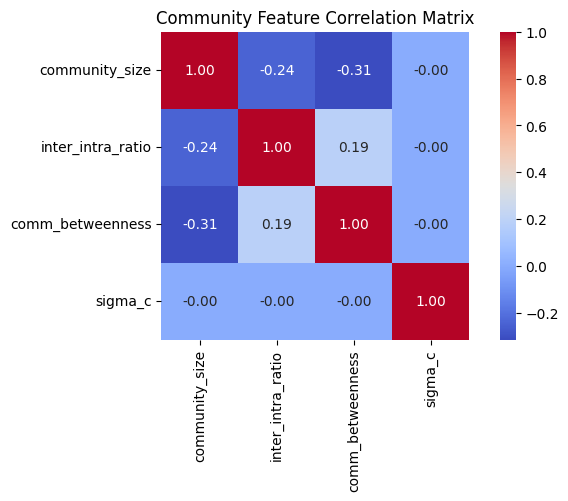

In [121]:
# plot feature covariance matrix
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = full_df[['community_size', 'inter_intra_ratio', 
                      'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 
                      'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 
                      'mu', 'sigma_c', 'M1', 'M2', 'ECS']].corr()
# print("Feature Correlation Matrix:")
# print(corr_matrix)
comm_corr_matrix = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'comm_closeness', 'sigma_c']].corr()
comm_corr_matrix = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness','sigma_c']].corr()
# comm_corr_matrix = full_df[['degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 'sigma_c']].corr()

plt.figure(figsize=(8, 4))
sns.heatmap(comm_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True )
plt.title("Community Feature Correlation Matrix")
plt.show()

In [116]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
for col, v in zip(X.columns, vif):
    print(f"{col}: VIF={v:.2f}")
# VIF > 5 (some say 10) indicates multicollinearity problem


community_size: VIF=1.47
inter_intra_ratio: VIF=1.35
comm_betweenness: VIF=1.24
sigma_c: VIF=1.50


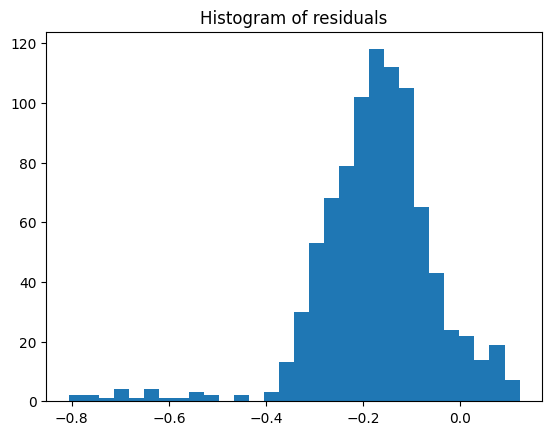

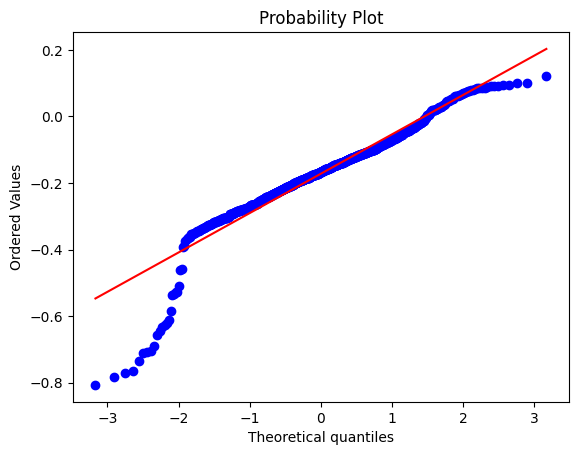

Shapiro-Wilk p-value: 7.505684046647909e-22
Kolmogorov-Smirnov p-value: 0.0016997456627911639


In [117]:
import scipy.stats as stats

residuals = m1 - linreg.predict(X_scaled)

# Histogram
plt.hist(residuals, bins=30)
plt.title("Histogram of residuals")
plt.show()

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

# Shapiro-Wilk test
print("Shapiro-Wilk p-value:", stats.shapiro(residuals)[1])
# p > 0.05 means residuals are likely normal

# Kolmogorov-Smirnov test
ks_stat, ks_p_value = stats.kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
print("Kolmogorov-Smirnov p-value:", ks_p_value)
# p > 0.05 means residuals are likely normal

In [118]:
from statsmodels.stats.stattools import durbin_watson
print("Durbin-Watson:", durbin_watson(residuals))
# Value ~2 is good; <1 or >3 means possible autocorrelation


Durbin-Watson: 0.30336465810990487


In [119]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Add constant to X for statsmodels
X_const = sm.add_constant(X_comm_level)
model = sm.OLS(m1, X_const).fit()
bp_test = het_breuschpagan(model.resid, model.model.exog)
print("Breusch-Pagan test p-value:", bp_test[1])
# p < 0.05 means heteroscedasticity is present


Breusch-Pagan test p-value: 1.0842479170804153e-28


Shapley Values

______________________

In [108]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = full_df[['community_size', 'inter_intra_ratio', 
                      'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 
                      'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean',  'sigma_c']]

X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'comm_closeness', 'sigma_c']]
X_node_level = full_df[['degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 'sigma_c']]
X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'sigma_c']]
X = X_node_level

m1 = full_df['M1']  
m2 = full_df['M2'] 
ecs = full_df['ECS']

X_train, X_test, y_train, y_test = train_test_split(X, m1, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train)
# sort the feature importances
feature_importances = dict(zip(X.columns, reg.feature_importances_))
feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))


print("Test R^2:", reg.score(X_test, y_test))
print("Feature importances for M1:")
for feature, importance in feature_importances.items():
    print(f"{feature}: {importance:.4f}")


Test R^2: 0.9543891702833047
Feature importances for M1:
betweenness_mean: 0.4263
sigma_c: 0.2260
closeness_mean: 0.2175
eigenvector_mean: 0.0864
degree_centrality_mean: 0.0438


In [109]:
import shap

# Create an explainer for the RandomForestRegressor
explainer = shap.TreeExplainer(reg)

# Calculate SHAP values for the training dataset
shap_values = explainer.shap_values(X_train)

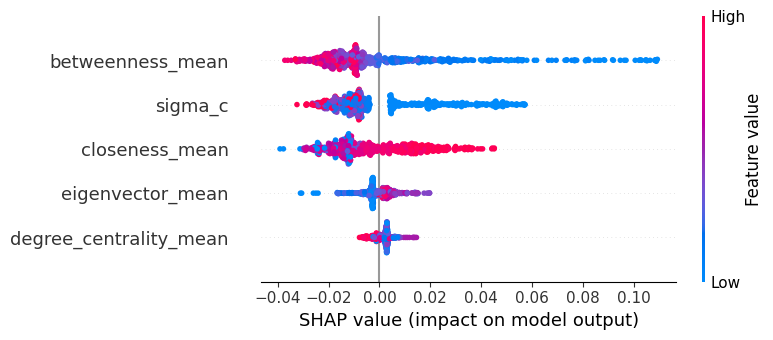

In [110]:
import shap
import matplotlib.pyplot as plt
features = X_train.columns.tolist()

shap.summary_plot(shap_values, X_train, feature_names=features)
plt.show()

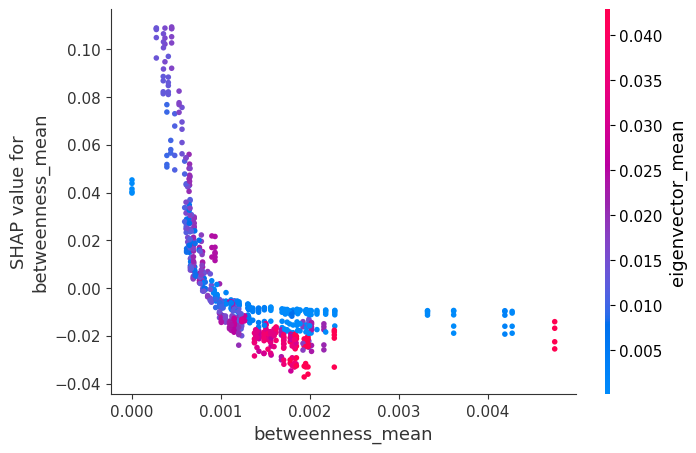

In [111]:
import shap
import matplotlib.pyplot as plt
feature_index = 1  # Change this to the index of the feature you want to plot

shap.dependence_plot(feature_index, shap_values, X_train, feature_names=features)
plt.show()

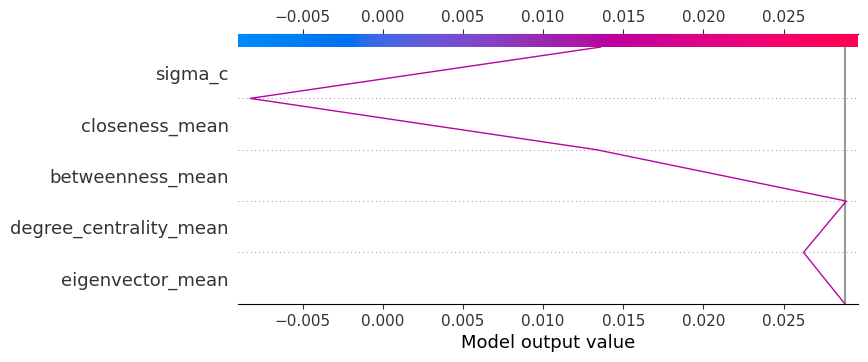

In [112]:
import shap
import matplotlib.pyplot as plt

# Assuming 'explainer' and 'shap_values' are available
shap.decision_plot(explainer.expected_value[0], shap_values[0], feature_names=features)
plt.show()

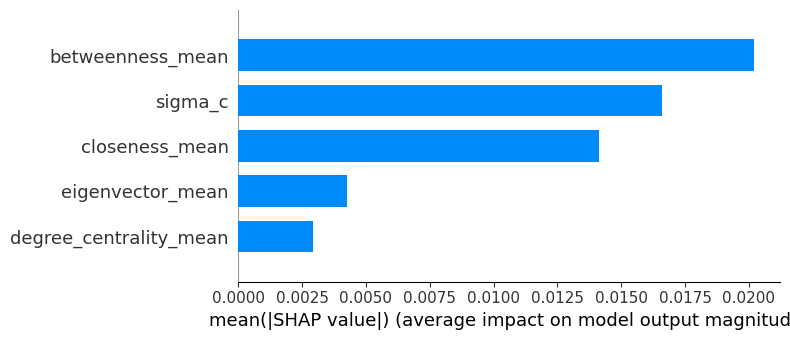

In [113]:
import shap
import matplotlib.pyplot as plt

features = X_train.columns.tolist()

shap.summary_plot(shap_values, X_train, feature_names=features, plot_type="bar")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, m2, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train)
# sort the feature importances
feature_importances = dict(zip(X.columns, reg.feature_importances_))
feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))


print("Test R^2:", reg.score(X_test, y_test))
# Built-in feature importance (Gini Importance)
print("Feature importances for M2:")
for feature, importance in feature_importances.items():
    print(f"{feature}: {importance:.4f}")

Test R^2: 0.9583315348248552
Feature importances for M2:
mu: 0.3333
sigma_c: 0.2769
inter_intra_ratio: 0.1790
comm_closeness: 0.0807
community_size: 0.0529
closeness_mean: 0.0519
degree_centrality_mean: 0.0069
betweenness_mean: 0.0068
eigenvector_mean: 0.0061
comm_betweenness: 0.0039
comm_degree_centrality: 0.0016


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, ecs, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train)
# sort the feature importances
feature_importances = dict(zip(X.columns, reg.feature_importances_))
feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))


print("Test R^2:", reg.score(X_test, y_test))
print("Feature importances for ECS:")
for feature, importance in feature_importances.items():
    print(f"{feature}: {importance:.4f}")

Test R^2: 0.9997903338703775
Feature importances for ECS:
mu: 0.5707
sigma_c: 0.3668
inter_intra_ratio: 0.0505
closeness_mean: 0.0092
eigenvector_mean: 0.0014
comm_closeness: 0.0010
comm_degree_centrality: 0.0004
betweenness_mean: 0.0000
community_size: 0.0000
degree_centrality_mean: 0.0000
comm_betweenness: 0.0000
